In [5]:
from sparseDPD import DataManager, DatapathPruningExperiment
from sparseDPD import Datapath
from sparseDPD import NeuralNetwork
from sparseDPD import PGJANET_NeuralNetwork
from sparseDPD import PNTDNN_NeuralNetwork
from sparseDPD import AdaptiveDatapathPruningExperiment
from sparseDPD import Volterra

import matplotlib.pyplot as plt

In [6]:
# load pretrained model
simpleDataManager = DataManager(filepath='UCD_datasets/PA_IO.mat', num_training_points=19000, num_validaiton_points=1000, num_test_points=2000)

PGJANET_forward_nn = PGJANET_NeuralNetwork(nn_file_path='pre_trained_models/pgjanet_checkpoint.pt', num_memory_levels=10, model_type='PGJANETNetwork', forward_model=True)


PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', forward_model=False)



Using cuda device
Using cuda device


Epoch  10/100  Loss=5.8830e+00  Valid Loss=1.5181e+01  LR=1.00e-03
Epoch  20/100  Loss=4.4537e+00  Valid Loss=1.2822e+01  LR=1.00e-03
Epoch  30/100  Loss=3.6447e+00  Valid Loss=9.9074e+00  LR=1.00e-03
Epoch  40/100  Loss=3.1397e+00  Valid Loss=7.4222e+00  LR=1.00e-03
Epoch  50/100  Loss=2.8314e+00  Valid Loss=6.0694e+00  LR=1.00e-03
Epoch  60/100  Loss=2.6003e+00  Valid Loss=5.3786e+00  LR=1.00e-03
Epoch  70/100  Loss=2.4378e+00  Valid Loss=5.0475e+00  LR=1.00e-03
Epoch  80/100  Loss=2.3279e+00  Valid Loss=4.8605e+00  LR=1.00e-03
Epoch  90/100  Loss=2.2619e+00  Valid Loss=4.7454e+00  LR=1.00e-03
Epoch 100/100  Loss=2.2099e+00  Valid Loss=4.6405e+00  LR=1.00e-03

Best model from epoch 100 with validation loss: 4.6405e+00
Iteration 1/15 - NMSE: -6.2875 dB
Epoch  10/100  Loss=7.0146e-01  Valid Loss=1.2468e+00  LR=1.00e-03
Epoch  20/100  Loss=5.7760e-01  Valid Loss=1.0024e+00  LR=1.00e-03
Epoch  30/100  Loss=5.1442e-01  Valid Loss=7.7792e-01  LR=1.00e-03
Epoch  40/100  Loss=4.8738e-01  Val

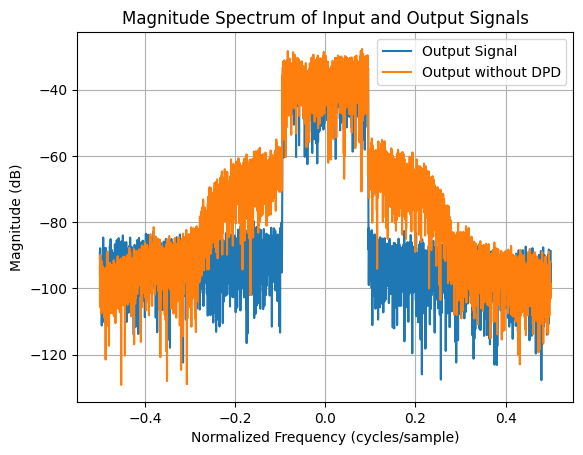

In [ ]:

datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_inverse_nn)
datapath.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 8,
    retrain_epochs_per_iteration=300
)

# find nmse
nmse = datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

In [ ]:
# Is this better than training with no ILA?
test_PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', forward_model=False) # So I dont end up training the real model here by accident
test_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=test_PNTDNN_inverse_nn)
test_datapath.train(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    epochs = 900
)
nmse_no_ila = test_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE without ILA: {nmse_no_ila:.4f} dB")

Epoch  10/900  Loss=3.9482e+00  Valid Loss=1.2766e-01  LR=1.00e-03
Epoch  20/900  Loss=1.0302e+00  Valid Loss=4.6009e-02  LR=1.00e-03
Epoch  30/900  Loss=6.2838e-01  Valid Loss=3.0405e-02  LR=1.00e-03
Epoch  40/900  Loss=5.3164e-01  Valid Loss=2.4771e-02  LR=1.00e-03
Epoch  50/900  Loss=5.1899e-01  Valid Loss=2.6677e-02  LR=1.00e-03
Epoch  60/900  Loss=4.1227e-01  Valid Loss=2.1310e-02  LR=5.00e-04
Epoch  70/900  Loss=4.0804e-01  Valid Loss=2.0774e-02  LR=5.00e-04
Epoch  80/900  Loss=4.0477e-01  Valid Loss=2.0297e-02  LR=5.00e-04
Epoch  90/900  Loss=3.9884e-01  Valid Loss=1.9859e-02  LR=5.00e-04
Epoch 100/900  Loss=3.9273e-01  Valid Loss=1.9511e-02  LR=5.00e-04
Epoch 110/900  Loss=3.8734e-01  Valid Loss=1.9232e-02  LR=5.00e-04
Epoch 120/900  Loss=3.8272e-01  Valid Loss=1.9010e-02  LR=5.00e-04
Epoch 130/900  Loss=3.7889e-01  Valid Loss=1.8833e-02  LR=5.00e-04
Epoch 140/900  Loss=3.7573e-01  Valid Loss=1.8687e-02  LR=5.00e-04
Epoch 150/900  Loss=3.7301e-01  Valid Loss=1.8570e-02  LR=5.00

ACLR with DPD - Lower: 33.89 dBc, Upper: 43.00 dBc
ACLR without DPD - Lower: 28.12 dBc, Upper: 27.79 dBc


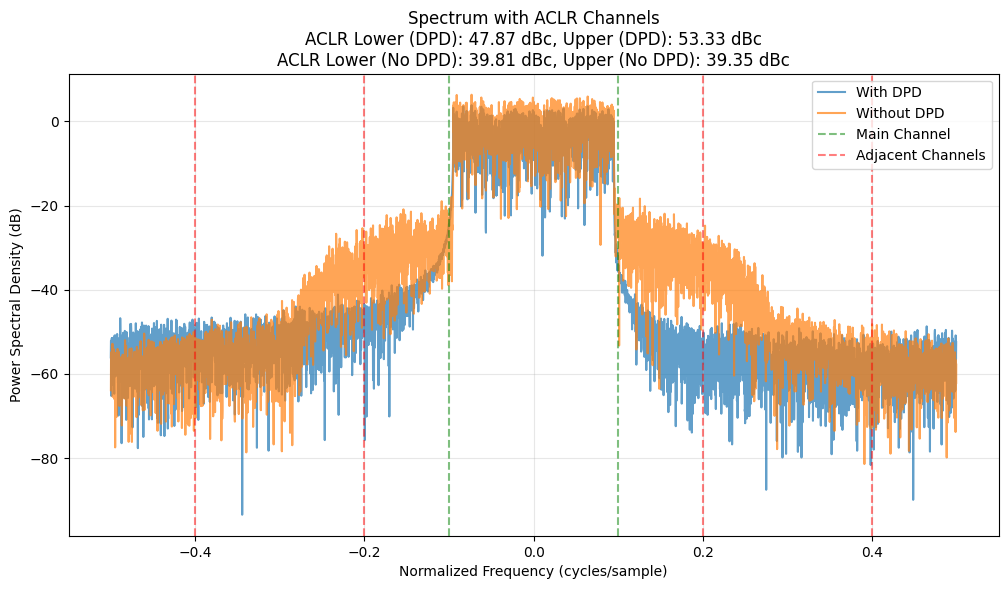

In [8]:
# Calculate ACLR metrics
aclr_results = datapath.calculate_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.1,        # Main channel bandwidth (10% of fs)
    channel_spacing=0.15,   # Adjacent channel offset (15% of fs)
    fs=1.0                  # Normalized sampling frequency
)

print(f"ACLR with DPD - Lower: {aclr_results['aclr_lower_dpd']:.2f} dBc, Upper: {aclr_results['aclr_upper_dpd']:.2f} dBc")
print(f"ACLR without DPD - Lower: {aclr_results['aclr_lower_no_dpd']:.2f} dBc, Upper: {aclr_results['aclr_upper_no_dpd']:.2f} dBc")

# Plot spectrum with ACLR channel boundaries marked
datapath.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>

Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 50 epochs...
Epoch  10/50  Loss=9.9191e-02  Valid Loss=8.1207e-03  LR=1.00e-03
Epoch  20/50  Loss=5.9475e-02  Valid Loss=6.6425e-03  LR=5.00e-04
Epoch  30/50  Loss=5.8610e-02  Valid Loss=7.2111e-03  LR=5.00e-04
Epoch  40/50  Loss=5.5240e-02  Valid Loss=6.3301e-03  LR=2.50e-04
Epoch  50/50  Loss=5.3563e-02  Valid Loss=6.6416e-03  LR=1.25e-04

Best model from epoch 38 with validation loss: 6.3107e-03
Epoch  10/50  Loss=6.8405e-02  Valid Loss=8.2946e-03  LR=1.00e-03
Epoch  20/50  Loss=6.8784e-02  Valid Loss=8.1436e-03  LR=1.00e-03
Epoch  30/50  Loss=8.5678e-02  Va

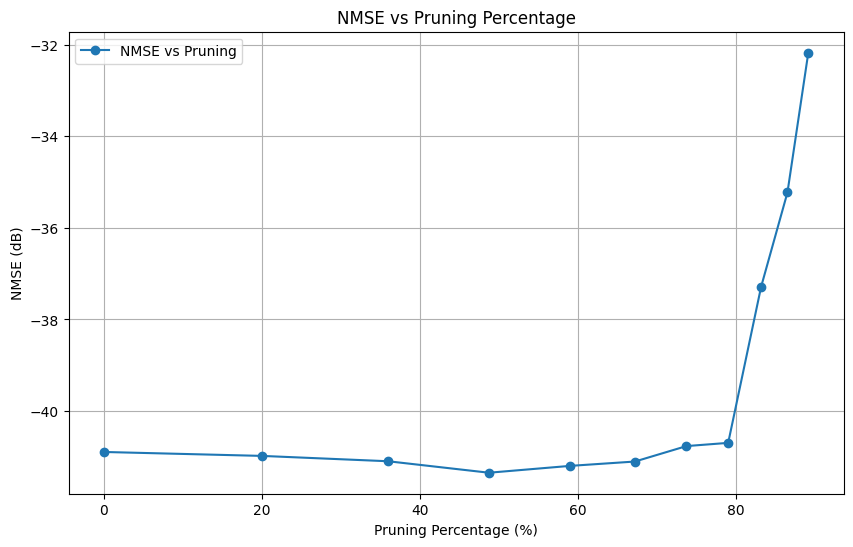

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Best NMSE after pruning: -40.6946 dB


In [4]:
# Now run the pruning experiment
pruning_experiment = DatapathPruningExperiment(
    datapath=datapath,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=50,
    ila_iterations = 5
)

pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(pruning_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Best NMSE after pruning: -40.6946 dB
Best model sparsity level: 79.03%
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>


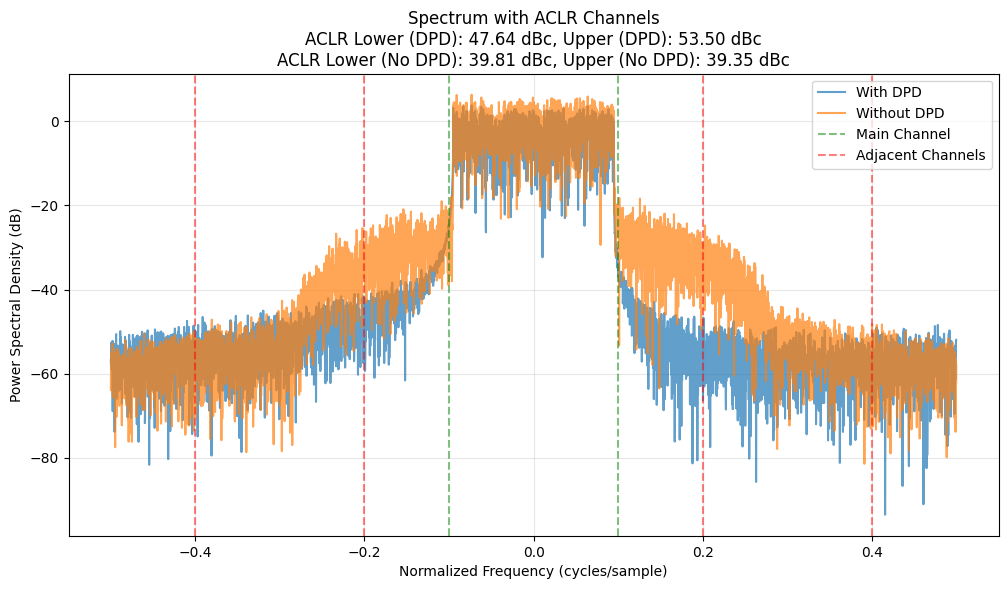

In [10]:
best_datapath = pruning_experiment.best_datapath
best_nmse = best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"Best NMSE after pruning: {best_nmse:.4f} dB")

# find the best model sparsity level
best_sparsity = best_datapath.inverse_model._get_pruning_percentage()
print(f"Best model sparsity level: {best_sparsity:.2f}%")

# Plot spectrum with ACLR channel boundaries marked
best_datapath.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)


Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=6.3978e-02  Valid Loss=6.8712e-03  LR=1.00e-03
Epoch  20/100  Loss=6.2279e-02  Valid Loss=6.6128e-03  LR=1.00e-03
Epoch  30/100  Loss=5.9508e-02  Valid Loss=6.4562e-03  LR=1.00e-03
Epoch  40/100  Loss=6.1728e-02  Valid Loss=6.4213e-03  LR=1.00e-03
Epoch  50/100  Loss=6.0914e-02  Valid Loss=6.4509e-03  LR=1.00e-03
Epoch  60/100  Loss=5.8418e-02  Valid Loss=6.3720e-03  LR=1.00e-03
Epoch  70/100  Loss=5.9572e-02  Valid Loss=6.3584e-03  LR=1.00e-03
Epoch  80/100  Loss=5.7968e-02  Valid Loss=6.3407e-03  LR=1.00e-03
Epoch  90/100  Loss=5.9176e-02  Valid Loss=6.3134e-03  LR=1.00e-03
Epoch 100/100  Loss=5.9933e-02  Valid Loss=6.3246e-03  LR=1.00e-03

Best model from epoch 98 with validation loss: 6.3066e-03
Iteration 1/3 - NMSE: -40.5473 dB
Epoch  10/100  Loss=6.3189e-02  Valid Loss=6.2739e-03  LR=1.00e-03
Epoch  20/100  Loss=6.3018e

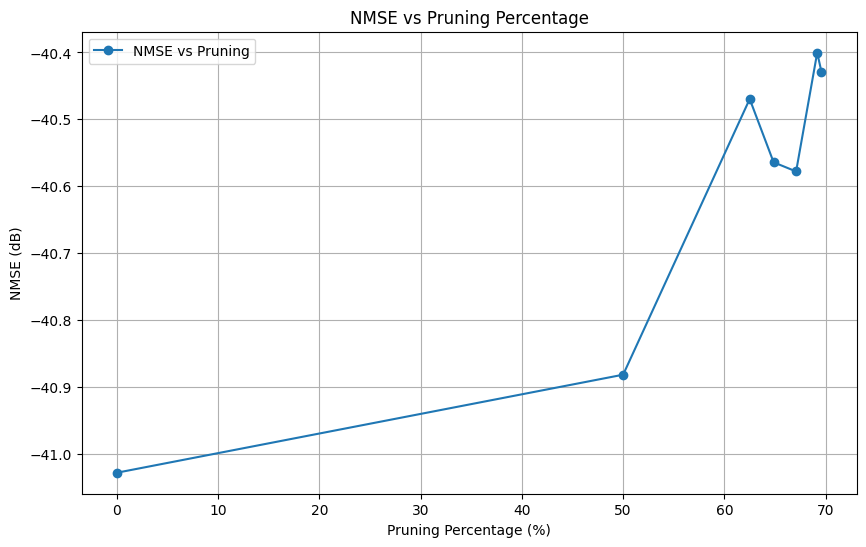

Best NMSE after pruning: -40.4288 dB


In [11]:
adaptive_pruning_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 3,
    initial_prune_fraction=0.5,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01
)

adaptive_pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Best NMSE after pruning: -39.5810 dB
Best model sparsity level: 92.50%
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>


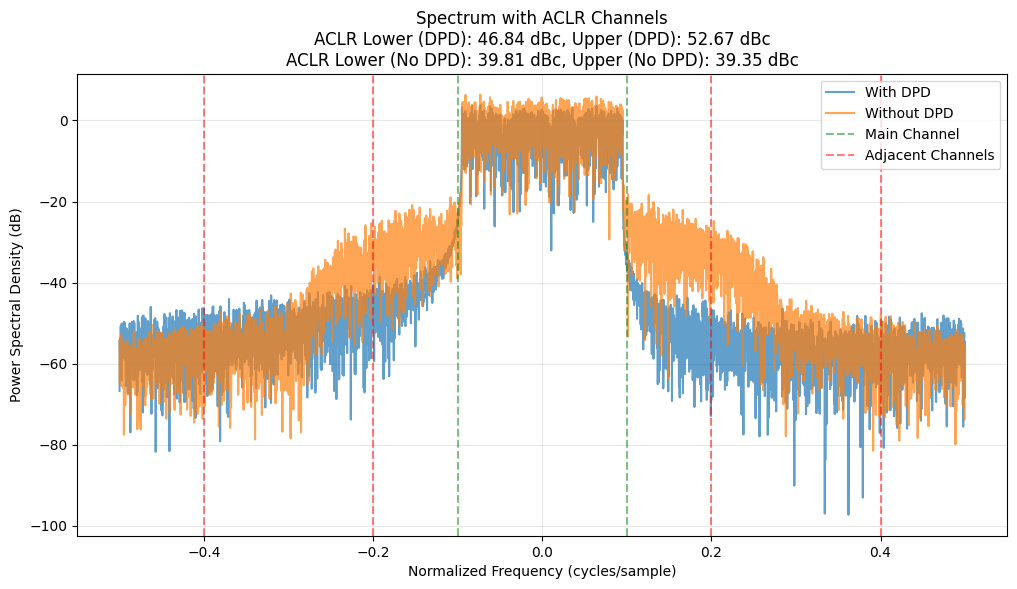

In [ ]:
# Plot the spectrum of the best model
best_datapath = adaptive_pruning_experiment.best_datapath
best_nmse = best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"Best NMSE after pruning: {best_nmse:.4f} dB")

# find the best model sparsity level
best_sparsity = best_datapath.inverse_model._get_pruning_percentage()
print(f"Best model sparsity level: {best_sparsity:.2f}%")

# Plot spectrum with ACLR channel boundaries marked
best_datapath.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)
# Also plot the input spectrum on the same graph

In [25]:
# Set a volterra model as the inverse to see what kind of results we get

volterra_inverse_model = Volterra(num_nl_orders=3, num_memory_levels=20, forward=False, dataset=simpleDataManager.training_dataset)

datapath_with_volterra = Datapath(forward_model=PGJANET_forward_nn, inverse_model=volterra_inverse_model)
datapath_with_volterra.calculate_nmse(simpleDataManager.test_dataset.input_data[:5000])

Your inverse model is type <class 'sparseDPD.Volterra.Volterra'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>


np.float64(-40.63966366254732)